In [1]:
import pandas as pd

In [2]:
latent_sm_train_1 = pd.read_csv("broken_experiment_data_model_4/latent_signature_matrix.csv", index_col=0)
latent_bulk_train_1 = pd.read_csv("broken_experiment_data_model_4/latent_bulk_data.csv", index_col=0)

latent_sm_train_2 = pd.read_csv("broken_experiment_data_model_5/latent_signature_matrix.csv", index_col=0)
latent_bulk_train_2 = pd.read_csv("broken_experiment_data_model_5/latent_bulk_data.csv", index_col=0)

latent_sm_no_train_1 = pd.read_csv("broken_no_train_v1_experiment_data_model_4/latent_signature_matrix.csv", index_col=0)
latent_bulk_no_train_1 = pd.read_csv("broken_no_train_v1_experiment_data_model_4/latent_bulk_data.csv", index_col=0)

latent_sm_no_train_2 = pd.read_csv("broken_no_train_v1_experiment_data_model_5/latent_signature_matrix.csv", index_col=0)
latent_bulk_no_train_2 = pd.read_csv("broken_no_train_v1_experiment_data_model_5/latent_bulk_data.csv", index_col=0)

latent_sm_no_train_1_v2 = pd.read_csv("broken_no_train_v2_experiment_data_model_4/latent_signature_matrix.csv", index_col=0)
latent_bulk_no_train_1_v2 = pd.read_csv("broken_no_train_v2_experiment_data_model_4/latent_bulk_data.csv", index_col=0)

latent_sm_no_train_2_v2 = pd.read_csv("broken_no_train_v2_experiment_data_model_5/latent_signature_matrix.csv", index_col=0)
latent_bulk_no_train_2_v2 = pd.read_csv("broken_no_train_v2_experiment_data_model_5/latent_bulk_data.csv", index_col=0)

latent_sm_1_no_train_2_v3 = pd.read_csv("broken_no_train_double_sampling_model_5/latent_signature_matrix_1.csv", index_col=0)
latent_bulk_1_no_train_2_v3 = pd.read_csv("broken_no_train_double_sampling_model_5/latent_bulk_data_1.csv", index_col=0)

latent_sm_2_no_train_2_v3 = pd.read_csv("broken_no_train_double_sampling_model_5/latent_signature_matrix_2.csv", index_col=0)
latent_bulk_2_no_train_2_v3 = pd.read_csv("broken_no_train_double_sampling_model_5/latent_bulk_data_2.csv", index_col=0)


In [6]:
latent_sm_1_no_train_2_v3.head()

,T,B,DC,NK,Mono
0,-0.141561,0.288395,0.627728,-0.115763,0.511082
1,-0.211483,0.069627,-0.483310,-0.394715,-0.630530
2,-0.184835,-0.380751,-0.713818,-0.070691,-0.389908
3,0.214995,0.115386,0.130374,0.246852,-0.573881
4,-0.195115,-1.055586,-0.780585,-0.252822,0.061255


In [7]:
latent_sm_2_no_train_2_v3.head()

,T,B,DC,NK,Mono
0,-0.141561,0.288395,0.627728,-0.115763,0.511082
1,-0.211483,0.069627,-0.483310,-0.394715,-0.630530
2,-0.184835,-0.380751,-0.713818,-0.070691,-0.389908
3,0.214995,0.115386,0.130374,0.246852,-0.573881
4,-0.195115,-1.055586,-0.780585,-0.252822,0.061255


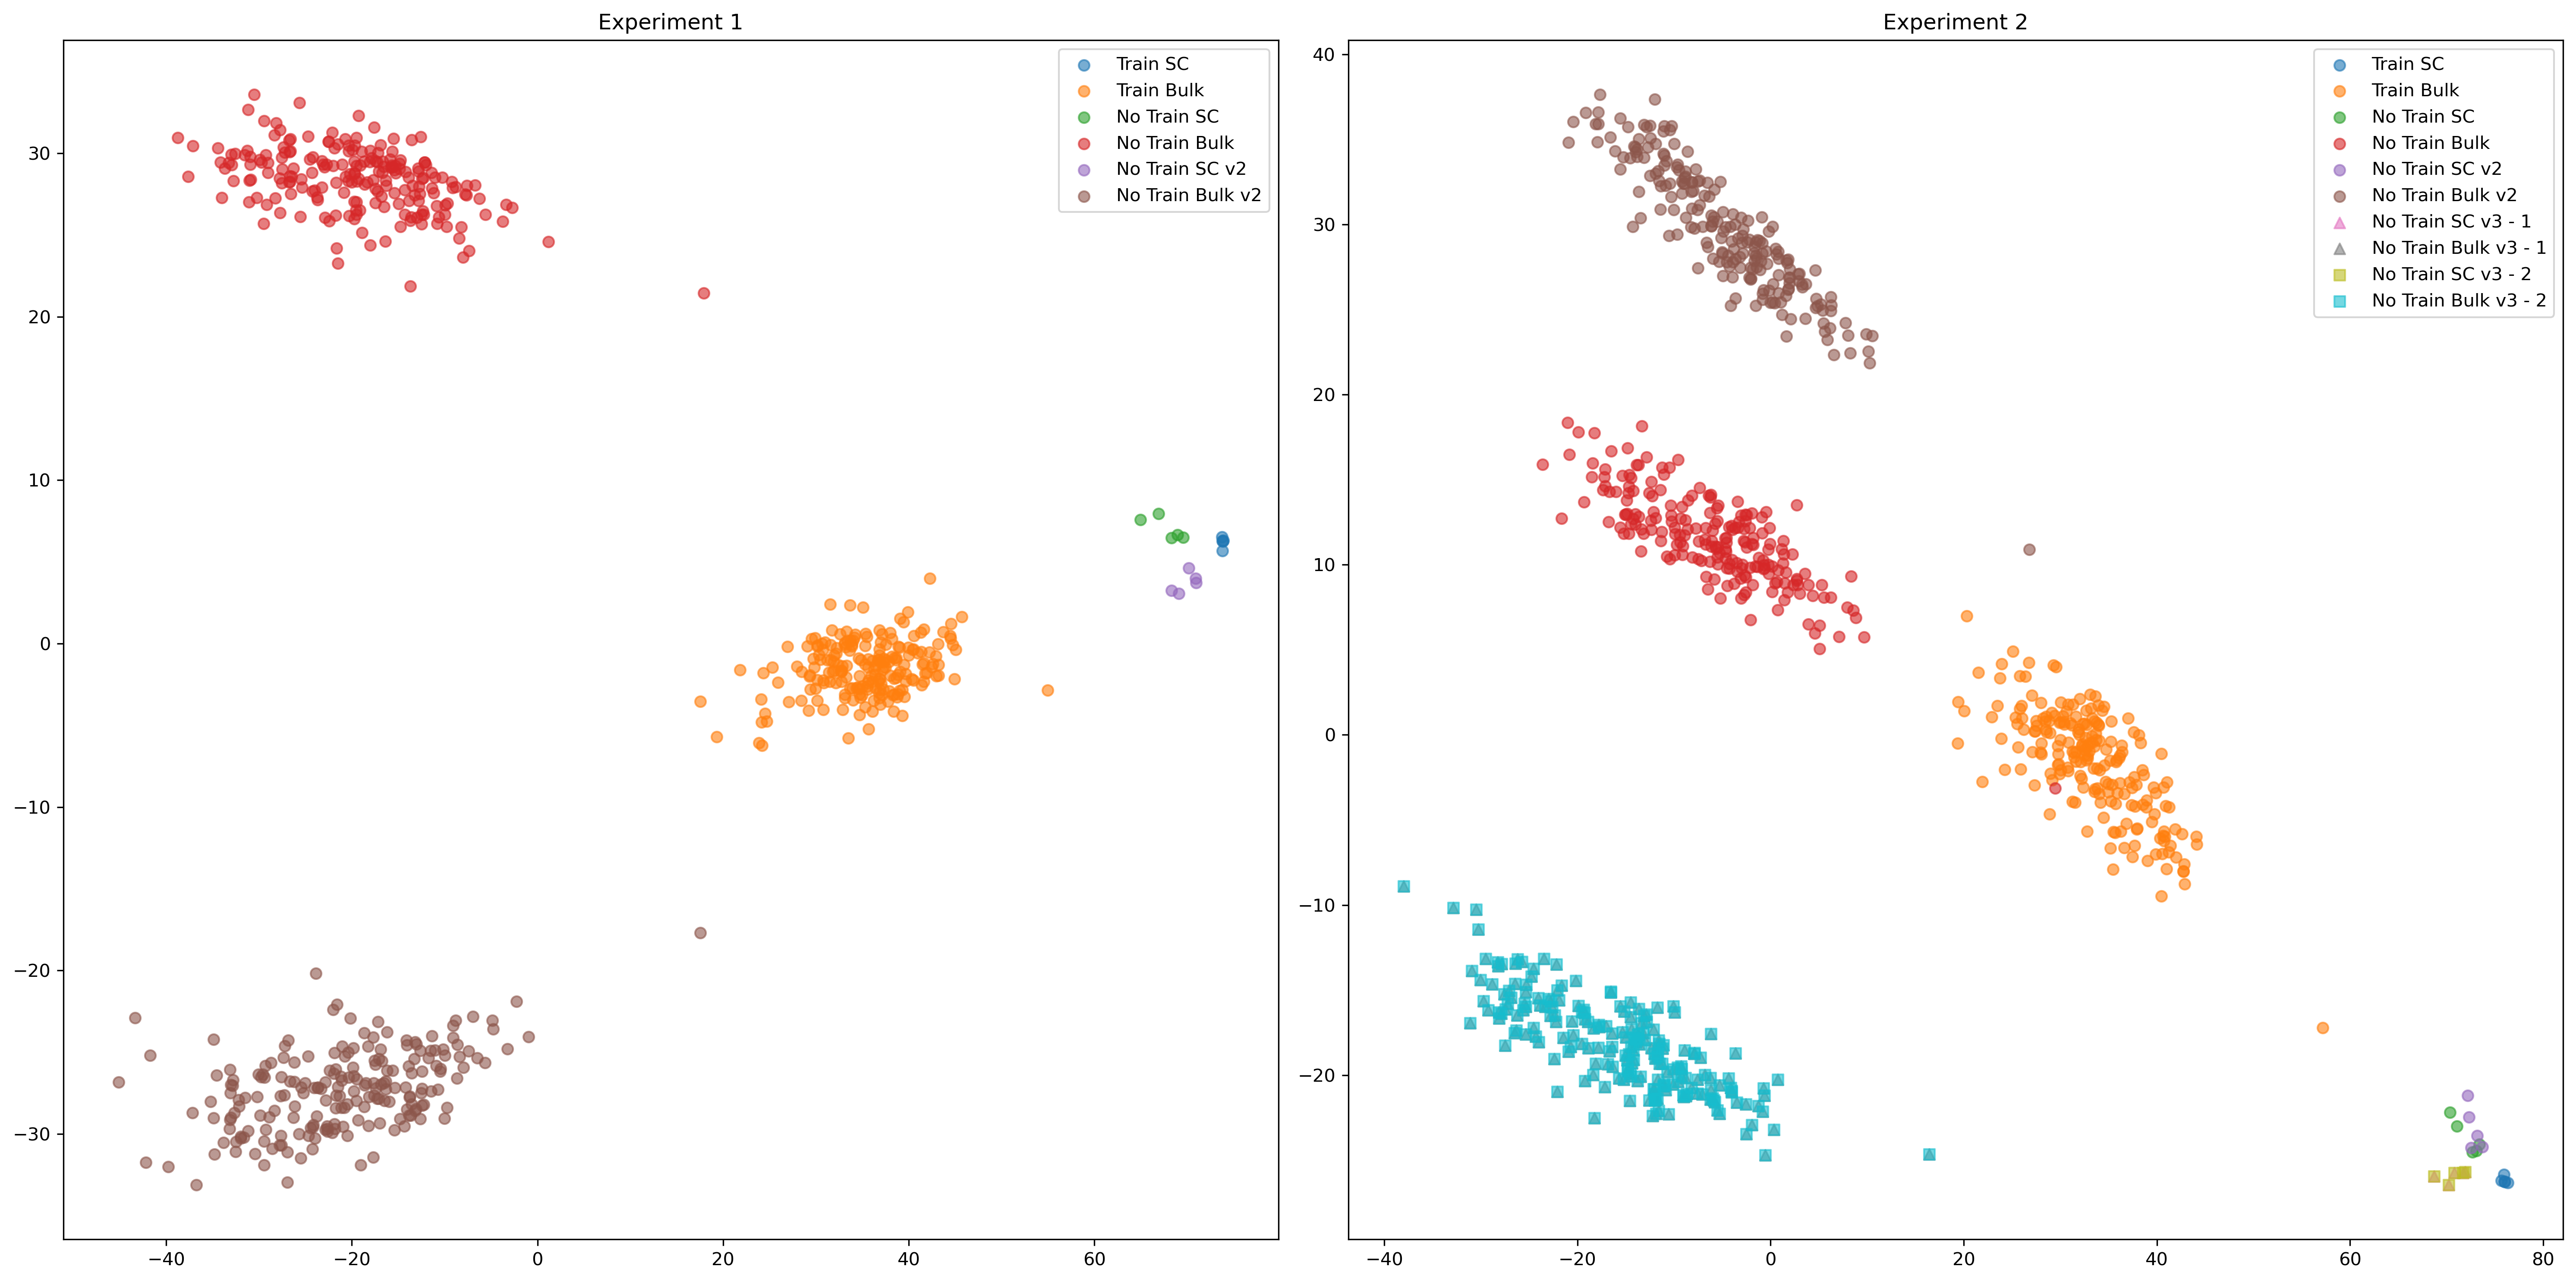

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -----------------------------
# Experiment 1
# -----------------------------
groups_exp1 = [
    latent_sm_train_1, latent_bulk_train_1,
    latent_sm_no_train_1, latent_bulk_no_train_1,
    latent_sm_no_train_1_v2, latent_bulk_no_train_1_v2
]

labels_exp1 = [
    "Train SC", "Train Bulk",
    "No Train SC", "No Train Bulk",
    "No Train SC v2", "No Train Bulk v2"
]

# Fit PCA on all samples from exp1
all_samples_1 = np.vstack([g.T for g in groups_exp1])
pca1 = PCA(n_components=2).fit(all_samples_1)

# Transform each group separately
embeddings_exp1 = [pca1.transform(g.T) for g in groups_exp1]

# -----------------------------
# Experiment 2
# -----------------------------
groups_exp2 = [
    latent_sm_train_2, latent_bulk_train_2,
    latent_sm_no_train_2, latent_bulk_no_train_2,
    latent_sm_no_train_2_v2, latent_bulk_no_train_2_v2,
    latent_sm_1_no_train_2_v3, latent_bulk_1_no_train_2_v3,
    latent_sm_2_no_train_2_v3, latent_bulk_2_no_train_2_v3
]

labels_exp2 = [
    "Train SC", "Train Bulk",
    "No Train SC", "No Train Bulk",
    "No Train SC v2", "No Train Bulk v2",
    "No Train SC v3 - 1", "No Train Bulk v3 - 1",
    "No Train SC v3 - 2", "No Train Bulk v3 - 2"
]

# Fit PCA on all samples from exp2
all_samples_2 = np.vstack([g.T for g in groups_exp2])
pca2 = PCA(n_components=2).fit(all_samples_2)

# Transform each group separately
embeddings_exp2 = [pca2.transform(g.T) for g in groups_exp2]

# -----------------------------
# Plot both experiments
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), dpi=300)

# --- Experiment 1 ---
for emb, label in zip(embeddings_exp1, labels_exp1):
    ax1.scatter(*emb.T, label=label, alpha=0.6)
ax1.set_title("Experiment 1")
ax1.legend()

# --- Experiment 2 ---
# Define marker styles: give special shapes to overlapping v3 groups
markers_exp2 = [
    'o',  # Train SC
    'o',  # Train Bulk
    'o',  # No Train SC
    'o',  # No Train Bulk
    'o',  # No Train SC v2
    'o',  # No Train Bulk v2
    '^',  # No Train SC v3 - 1 (triangle up)
    '^',  # No Train Bulk v3 - 1
    's',  # No Train SC v3 - 2 (square)
    's'   # No Train Bulk v3 - 2
]

for emb, label, marker in zip(embeddings_exp2, labels_exp2, markers_exp2):
    ax2.scatter(*emb.T, label=label, alpha=0.6, marker=marker)

ax2.set_title("Experiment 2")
ax2.legend()

plt.tight_layout()
plt.show()


### THE PROBLEM COULD BE THE FACT THAT WE NEED TO LOAD THE MODEL WITH THE SAME DATA IT WAS TRAINED ([check here](https://github.com/owkin/deepdeconv-fork/blob/a2928d1f33493e0ba50db2abef79da1abc8e8196/scvi/model/base/_base_model.py#L630))

In [3]:
original_bulk_data_1 = pd.read_csv("broken_experiment_data_model_4/original_bulk_data.csv", index_col=0)
original_bulk_data_1.head()

,3003,4015,5003,6011,6013,6014,8002,8003,10003,13007,...,14002,14004,20001,20002,20003,20004,20005,21002,22001,22002
ENSG00000287498,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.957619,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000125740,900.580902,229.907345,486.082048,576.951412,1532.739507,1268.717153,112.271229,1341.903458,480.479141,177.137368,...,1489.206809,470.908546,11566.541270,22800.643964,19609.520182,2553.618373,1613.163525,548.484720,5641.089202,511.391822
ENSG00000181690,142.068975,488.440939,442.887378,305.107424,259.317380,215.603695,290.570839,177.438937,385.747549,429.898444,...,85.758829,103.375321,225.002677,108.021541,85.577305,120.307434,249.825449,162.271274,119.280097,193.930677
ENSG00000224243,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.610129,0.000000,0.000000,...,0.000000,0.000000,10.458874,0.000000,0.000000,1.546188,3.062668,0.000000,0.000000,0.000000
ENSG00000091128,5.088434,0.000000,1.951703,4.002709,2.174538,0.935224,0.000000,0.000000,7.993028,4.219295,...,1.966991,5.446809,7.976422,1.186424,0.000000,5.764246,0.000000,1.131147,0.000000,0.000000


In [10]:
original_signature_matrix_1 = pd.read_csv("broken_experiment_data_model_4/original_signature_matrix.csv", index_col=0)
original_signature_matrix_1.head()

,T,B,DC,NK,Mono
Genes,,,,,
ENSG00000145649,1.975000,0.009372,0.068604,4.561983,0.020686
ENSG00000115523,2.246429,0.031362,0.335755,31.245287,0.091396
ENSG00000125148,1.490734,0.255842,2.495561,2.959650,4.997692
ENSG00000271503,6.825000,0.141066,0.241324,8.119354,0.103511
ENSG00000008517,5.646831,0.034445,0.443906,2.150075,0.045822


In [9]:
original_bulk_data_1_v1 = pd.read_csv("broken_no_train_v1_experiment_data_model_4/original_bulk_data.csv", index_col=0)
original_bulk_data_1_v1.head()


,3003,4015,5003,6011,6013,6014,8002,8003,10003,13007,...,14002,14004,20001,20002,20003,20004,20005,21002,22001,22002
ENSG00000145287,2089.670051,1973.622994,2115.297210,2263.756666,1910.218947,1905.588282,2761.657361,1747.266538,1495.680655,2082.807072,...,1320.832689,2878.180889,826.427780,818.052953,914.297121,627.595165,674.280887,709.940290,782.082061,612.837967
ENSG00000156920,6.099975,5.105875,6.266901,2.054338,2.986216,5.127437,0.000000,1.039294,4.036709,4.389149,...,0.000000,0.949207,1.890363,0.000000,2.887754,1.035060,3.865682,1.973114,2.923233,1.965296
ENSG00000143367,51.834943,58.722290,43.043673,42.145666,26.457690,62.384446,17.390117,67.337755,66.962906,42.753862,...,23.902762,15.082423,46.252996,35.361974,44.655985,33.305176,40.455967,39.359074,38.333447,32.276752
ENSG00000155324,125.391522,181.363062,141.738686,189.848137,112.057172,94.473581,121.229168,101.315386,83.504594,173.870039,...,77.481693,141.401151,133.673869,61.456540,121.158927,63.183911,80.237938,69.876004,73.845823,59.661324
ENSG00000180318,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [11]:
original_signature_matrix_1_v1 = pd.read_csv("broken_no_train_v1_experiment_data_model_4/original_signature_matrix.csv", index_col=0)
original_signature_matrix_1_v1.head()

,T,B,DC,NK,Mono
Genes,,,,,
ENSG00000145649,1.975000,0.009372,0.068604,4.561983,0.020686
ENSG00000115523,2.246429,0.031362,0.335755,31.245287,0.091396
ENSG00000125148,1.490734,0.255842,2.495561,2.959650,4.997692
ENSG00000271503,6.825000,0.141066,0.241324,8.119354,0.103511
ENSG00000008517,5.646831,0.034445,0.443906,2.150075,0.045822


In [12]:
from benchmark_utils import (
    use_nnls_method,
)

deconv_results_1 = use_nnls_method(original_bulk_data_1, original_signature_matrix_1)
deconv_results_1_v1 = use_nnls_method(original_bulk_data_1_v1, original_signature_matrix_1_v1)

deconv_results_1.head()




,T,B,DC,NK,Mono
3003,0.406687,0.083202,0.000000,0.0,0.510111
4015,0.772720,0.080499,0.008927,0.0,0.137854
5003,0.666834,0.090250,0.009278,0.0,0.233638
6011,0.545322,0.091309,0.000000,0.0,0.363368
6013,0.610171,0.145256,0.048409,0.0,0.196164


In [13]:
deconv_results_1_v1.head()

,T,B,DC,NK,Mono
3003,0.406687,0.083202,0.000000,0.0,0.510111
4015,0.772720,0.080499,0.008927,0.0,0.137854
5003,0.666834,0.090250,0.009278,0.0,0.233638
6011,0.545322,0.091309,0.000000,0.0,0.363368
6013,0.610171,0.145256,0.048409,0.0,0.196164
